In [1]:
#@python 3.8.10
#@author moon ying
#plot continuum membrane results with matplotlib 3d plot and trimesh package
#dependencies are listed as follows

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import trimesh as tr
import re
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import numpy as np
import seaborn as sns
sns.set_context("talk")

import pyvista as pv
import vtk
from pyvistaqt import BackgroundPlotter

# use one of...
from pykdtree.kdtree import KDTree
# from scipy.spatial import cKDTree as KDTree

In [2]:
# input and output file name string
infile = "vertexfinal.csv"
outfile = "change_density"

# controls if figure legends are included
is_legend_plotted = False

In [3]:
vertices = pd.read_csv(infile, header = None)
vertices.columns = ["x","y","z"]
vertices

,x,y,z
0,-147.550331,-151.614896,29.109548
1,-142.641008,-151.609666,29.109637
2,-138.137615,-151.605851,29.109698
3,-131.336981,-151.603525,29.109612
4,-127.233417,-151.604660,29.109530
...,...,...,...
4326,131.862385,151.605851,29.109745
4327,136.399286,151.603356,29.109801
4328,142.766583,151.604660,29.109559
4329,147.584314,151.612809,29.109476


# Plot exaggerated

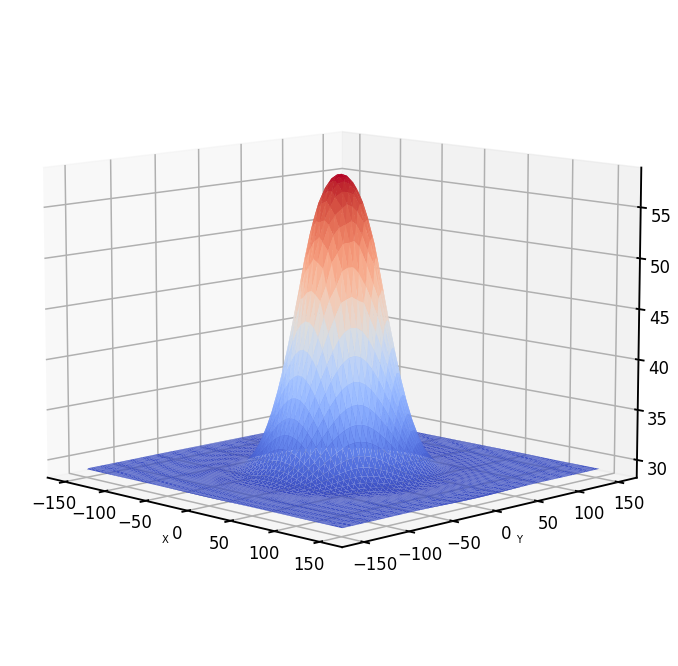

In [4]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')

#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
surf = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], cmap=cm.coolwarm)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev = 10, azim = -45)
plt.savefig(outfile + "gagsonly_10deg_with_axis.svg", format = 'svg')

# Read in the COM.csv and apply total shift from .log file

In [5]:
# Read in the Gag lattice file
gags = pd.read_csv("COM.csv", header = None, skiprows = 1)
gags.columns = ["x","y","z"]

# Define the log file name that contains the total membrane propagation vector
log_file = "output100.log"

# Define the pattern to search for with regular expression
pattern =re.compile(r"\[Mesh::propagate_scaffolding\(\)\] Total movement : \((-?\d+\.\d+), (-?\d+\.\d+), (-?\d+\.\d+)\)")

# Read the file and find the last matching line
last_match = None
with open(log_file, "r") as file:
    for line in file:
        match = pattern.search(line)
        if match:
            last_match = match

# If a match was found, extract the coordinates and save to a numpy array
if last_match:
    coordinates = np.array([float(last_match.group(1)),
                            float(last_match.group(2)), float(last_match.group(3))])
    print("Extracted Coordinates:", coordinates)
else:
    print("No matching line found in the log file.")

gag_lattices_shift = coordinates
gags["x"] = gags["x"] + gag_lattices_shift[0]
gags["y"] = gags["y"] + gag_lattices_shift[1]
gags["z"] = gags["z"] + gag_lattices_shift[2]
gags["z"] -= min(vertices["z"])
vertices["z"] -= min(vertices["z"])
df = gags
gags

Extracted Coordinates: [-0.426671  0.158268 -0.485336]


,x,y,z
0,24.534251,-9.848072,12.831545
1,20.226405,-2.567574,16.132631
2,6.094745,29.440876,10.679136
3,-16.411159,25.545196,10.679136
4,7.176063,-6.740127,19.613895
...,...,...,...
236,-24.875233,-17.227584,10.679136
237,-26.828427,14.404224,10.679136
238,10.457370,25.163590,12.587029
239,13.753082,-10.203516,17.493322


# Plot results and COM.csv

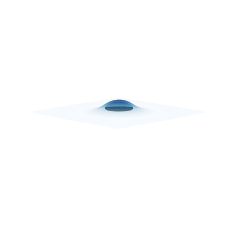

In [6]:
## fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-150.0, 150.0)
ax.set_ylim3d(-150.0, 150.0)
ax.set_zlim3d(-150.0, 150.0)
# Force equal scaling in 3D
ax.set_box_aspect([1, 1, 1])
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 10, azim = 45)

plt.savefig(outfile + "gags_membrane_10deg_uniform_scale.svg", format = 'svg')

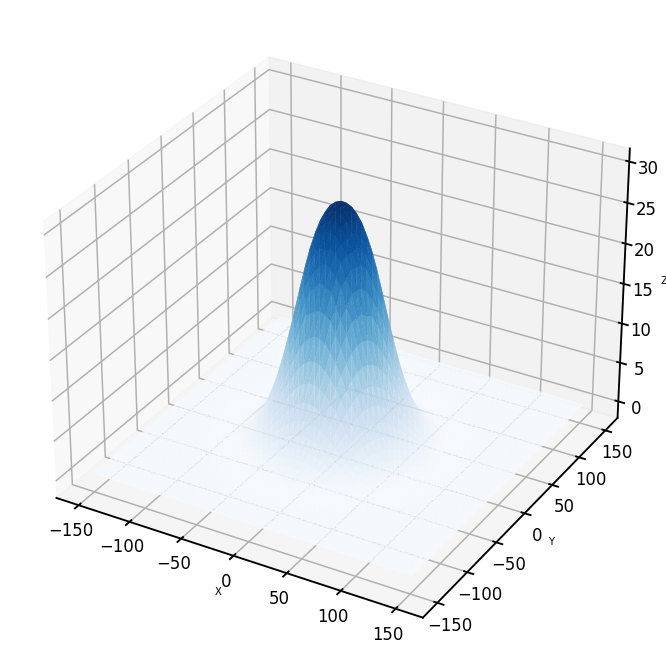

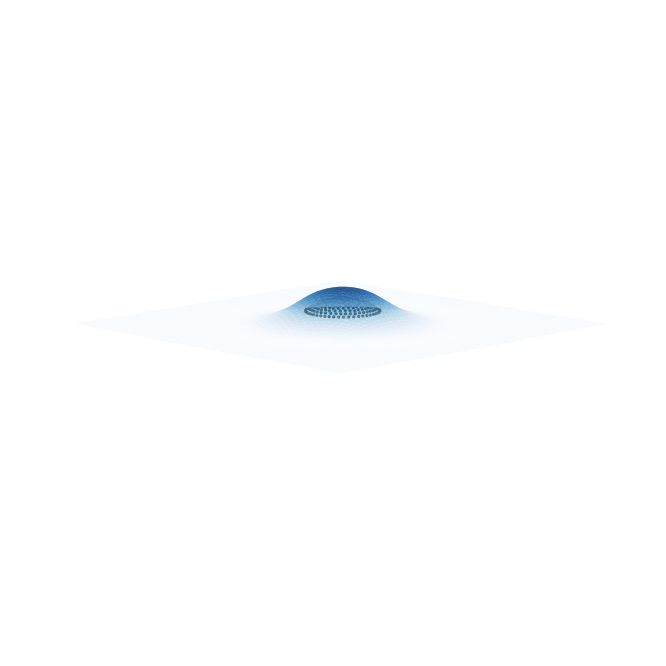

In [7]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.95, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-150.0, 150.0)
ax.set_ylim3d(-150.0, 150.0)
ax.set_zlim3d(-150.0, 150.0)
# Force equal scaling in 3D
ax.set_box_aspect([1, 1, 1])
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 10, azim = 45)


plt.savefig(outfile + "gags_membrane_10deg_uniform_scale_with_axis.svg", format = 'svg')

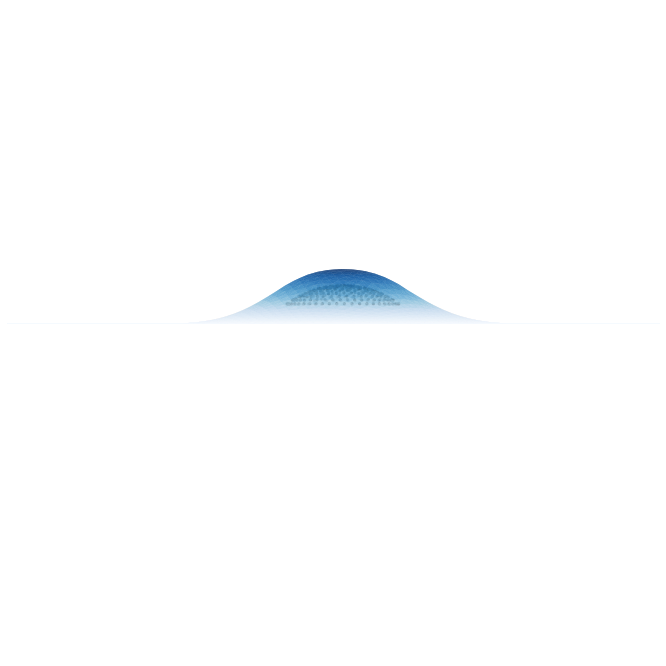

In [8]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
# Force equal scaling in 3D
ax.set_box_aspect([1, 1, 1])
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 0, azim = 45)

plt.savefig(outfile + "gags_membrane_0deg_uniform_zscale.svg", format = 'svg')

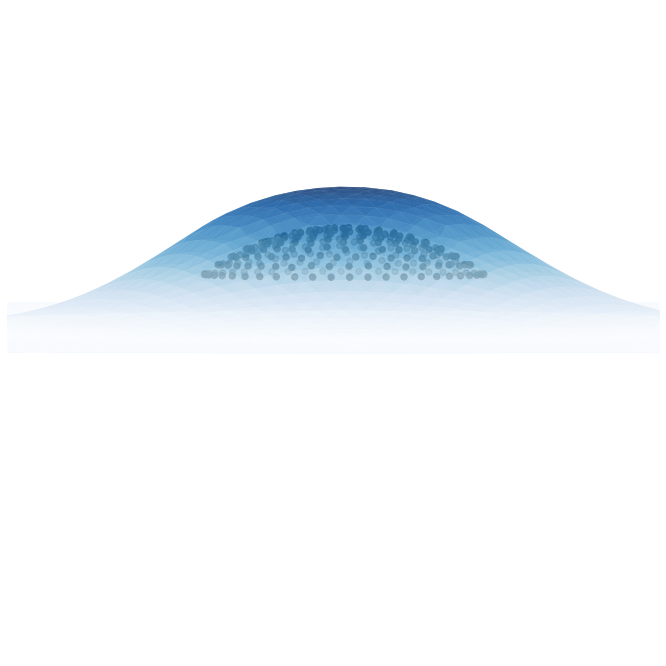

In [9]:
fig = plt.figure(figsize=(12, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.6, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 35, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-40.0, 40.0)
ax.set_ylim3d(-40.0, 40.0)
ax.set_zlim3d(-40.0, 40.0)
# Force equal scaling in 3D
ax.set_box_aspect([1, 1, 1])
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 2, azim = 90)

plt.savefig(outfile + "gags_membrane_2deg_uniform_zscale_zoomin2x.svg", format = 'svg')

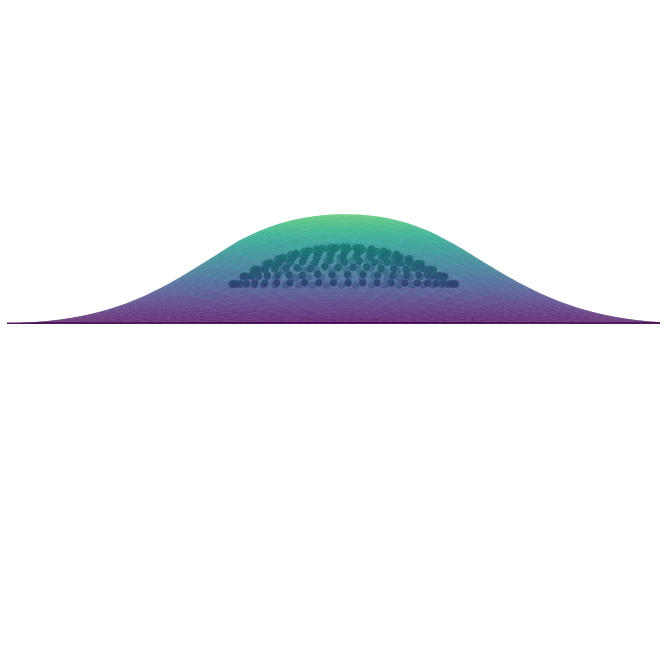

In [11]:
fig = plt.figure(figsize=(12, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"] - min( vertices["z"]), \
                                cmap="viridis", alpha = 0.6, label = "membrane", vmin = 0.0, vmax = 40.0)
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"]- min( vertices["z"]), s = 35, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-50.0, 50.0)
ax.set_ylim3d(-50.0, 50.0)
ax.set_zlim3d(-50.0, 50.0)
# Force equal scaling in 3D
ax.set_box_aspect([1, 1, 1])
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 0, azim = 90)

plt.savefig(outfile + "gags_membrane_2deg_uniform_zscale_zoomin2x_viridis.svg", format = 'svg')
plt.savefig("/Users/yueying/Downloads/den0_membrane_0deg_uniform_zscale_zoomin2x_viridis.svg", format = 'svg')

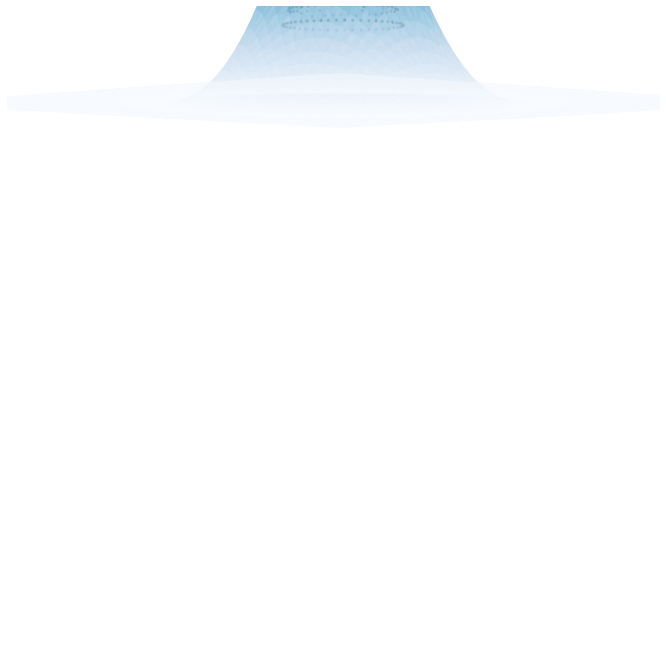

In [11]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-20.0, 20.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 0, azim = 45)

plt.savefig(outfile + "gags_membrane_0deg_5x_zscale.svg", format = 'svg')

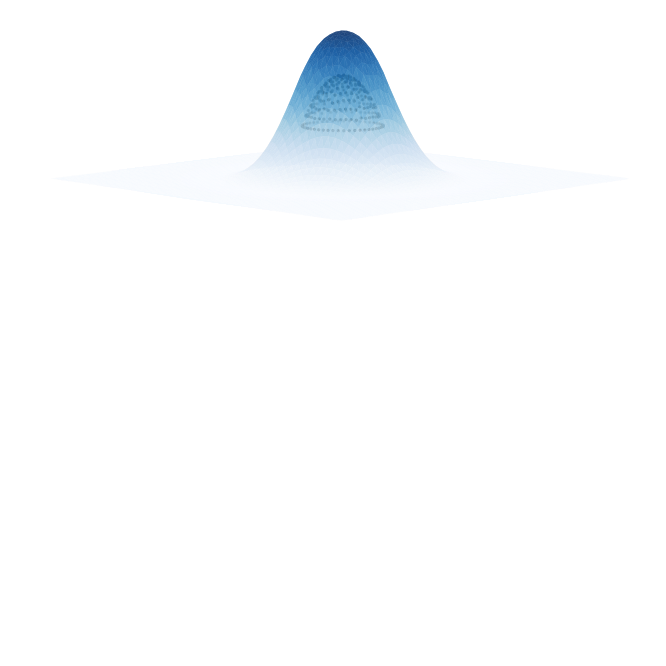

In [12]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-150.0, 150.0)
ax.set_ylim3d(-150.0, 150.0)
ax.set_zlim3d(-30.0, 30.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 10, azim = 45)

plt.savefig(outfile + "gags_membrane_10deg_5x_zscale.svg", format = 'svg')

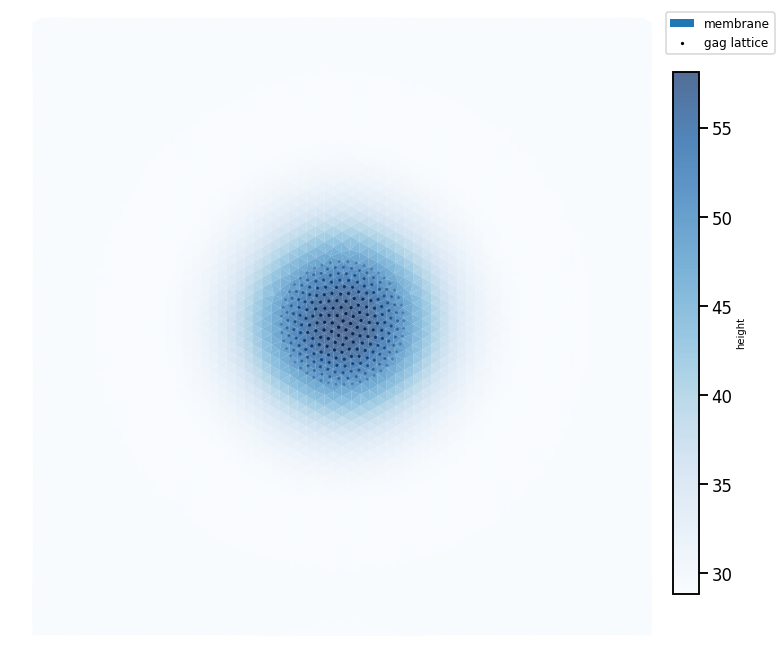

In [13]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

# Color bar
cbar = fig.colorbar(surf_vertices, shrink = 0.8, pad = 0.01)
cbar.set_label('height')

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_membrane_topdown_uniform_zscale.svg", format = 'svg')

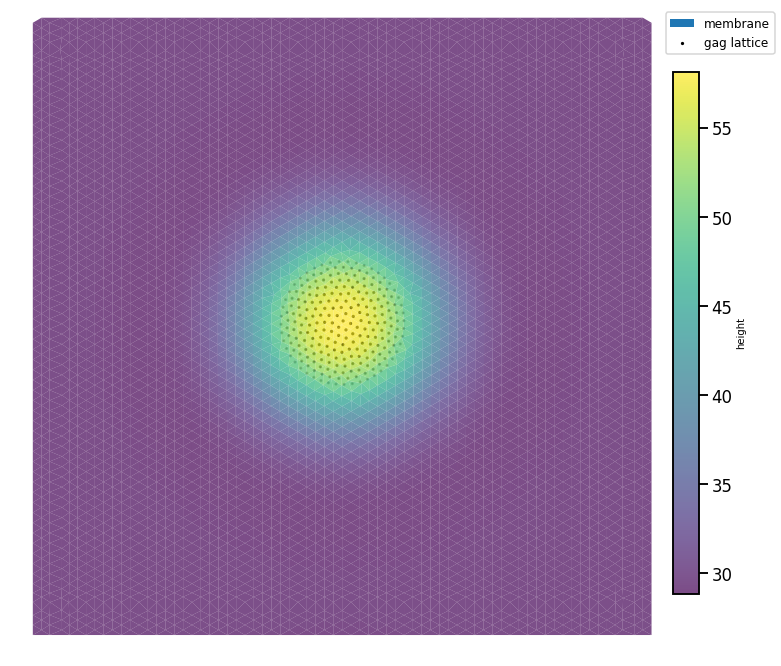

In [14]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="viridis", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

# Color bar
cbar = fig.colorbar(surf_vertices, shrink = 0.8, pad = 0.01)
cbar.set_label('height')

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_membrane_topdown_uniform_zscale_viridis.svg", format = 'svg')

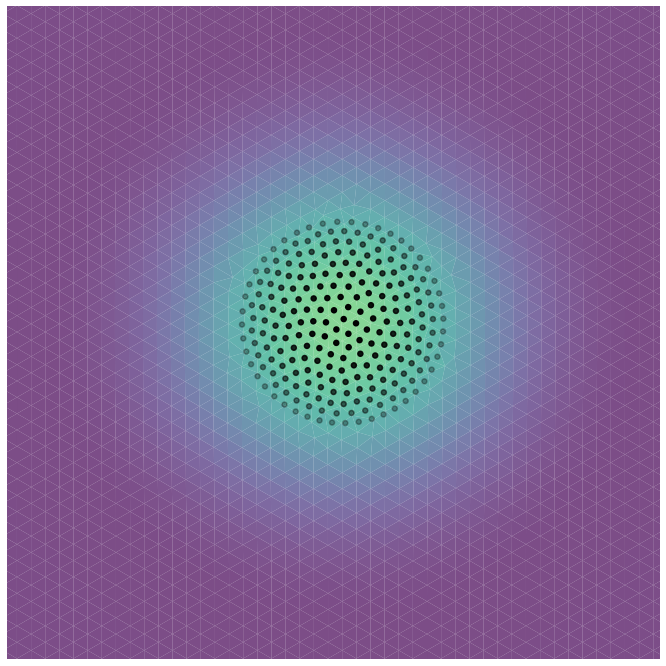

In [38]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"] - min( vertices["z"]), \
                                cmap="viridis", alpha = 0.7, label = "membrane",
                               vmin = 0.0, vmax = 40.0)
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors


scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 25, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-60.0, 60.0)
ax.set_ylim3d(-60.0, 60.0)
ax.set_zlim3d(-20.0, 100.0)
ax.set_axis_off()
#ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_membrane_topdown_uniform_zscale_viridis_no_tags.svg", format = 'svg')

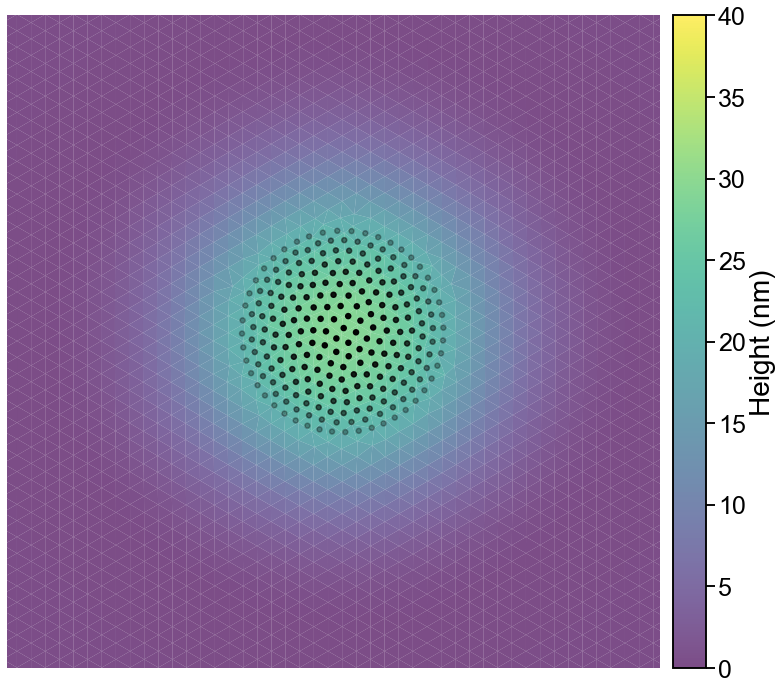

In [39]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"] -min( vertices["z"]), \
                                cmap="viridis", alpha = 0.7, label = "membrane",
                               vmin = 0.0, vmax = 40.0)
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

# Colorbar
cbar = fig.colorbar(surf_vertices, pad=0.01)
cbar.set_label('Height (nm)', fontsize=28, fontname='Arial')

# Set colorbar ticks font
cbar.ax.tick_params(labelsize=25)
for label in cbar.ax.get_yticklabels():
    label.set_fontname('Arial')


scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 25, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-60.0, 60.0)
ax.set_ylim3d(-60.0, 60.0)
ax.set_zlim3d(-20.0, 100.0)
ax.set_axis_off()
#ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_membrane_topdown_uniform_zscale_viridis.svg", format = 'svg')

# PyVista Subdivide


In [16]:
df_faces = pd.read_csv("face.csv", header = None)
faces = df_faces.to_numpy()
faces

array([[  61,   62,    0],
       [  62,    1,    0],
       [  62,   63,    1],
       ...,
       [4328, 4329, 4268],
       [4268, 4329, 4269],
       [4329, 4330, 4269]])

In [17]:
# VTK requires mesh faces info stores as [num_vertices, vertex1, vertex2, ...]
df_faces.insert(0, 'num', 3)
vtk_faces = df_faces.to_numpy()
vtk_faces

array([[   3,   61,   62,    0],
       [   3,   62,    1,    0],
       [   3,   62,   63,    1],
       ...,
       [   3, 4328, 4329, 4268],
       [   3, 4268, 4329, 4269],
       [   3, 4329, 4330, 4269]])

## Loop Subdivision


In [18]:
subdiv_times = 4
subfilter = "loop"

arr_x = vertices["x"].to_numpy()
arr_y = vertices["y"].to_numpy()
arr_z = vertices["z"].to_numpy()

npdat = np.transpose(np.array([arr_x, arr_y, arr_z]))

# Convert the numpy array into a pyvista mesh object
mesh = pv.PolyData(npdat, vtk_faces)

# Subdivide with pyvista module
# currently `subfilter` field supports three schemes: linear, loop, butterfly
meshsub = mesh.subdivide(subdiv_times, subfilter=subfilter)
meshsub


PolyData,Information
N Cells,2150400
N Points,1077281
N Strips,0
X Bounds,"-1.492e+02, 1.517e+02"
Y Bounds,"-1.516e+02, 1.516e+02"
Z Bounds,"2.884e+01, 5.816e+01"
N Arrays,0


In [19]:
vertices_subdiv = meshsub.points.T
vertices_subdiv

pyvista_ndarray([[-147.14606 , -142.7084  , -137.75624 , ...,
                   150.16866 ,  150.05717 ,  149.88617 ],
                 [-150.90811 , -151.6099  , -151.6061  , ...,
                   150.24998 ,  150.00067 ,  150.2653  ],
                 [  29.109566,   29.109632,   29.109674, ...,
                    29.109499,   29.109493,   29.109497]], dtype=float32)

KeyboardInterrupt: 

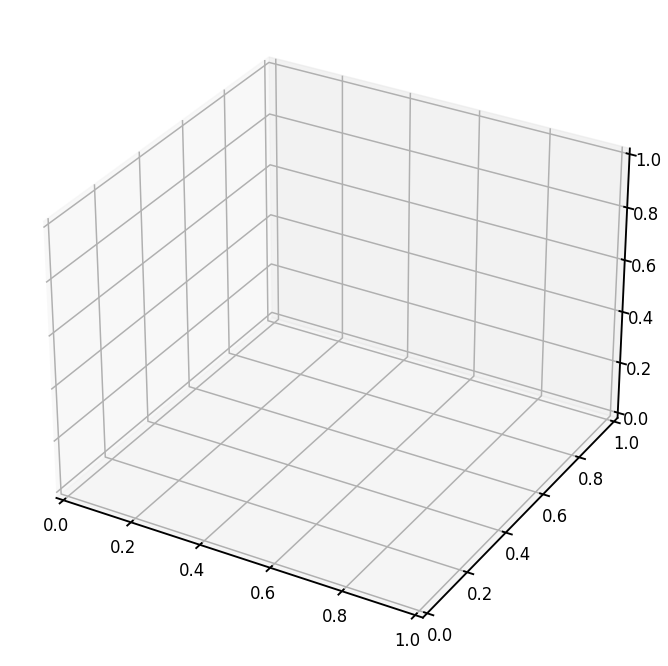

In [20]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})



surf_subdiv = ax.plot_trisurf(vertices_subdiv[0], \
                                vertices_subdiv[1],
                                vertices_subdiv[2], \
                               cmap = "Blues", alpha = 1.0, edgecolor="none", label = "Limit Surface")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_subdiv._facecolors2d=surf_subdiv._facecolors
surf_subdiv._edgecolors2d=surf_subdiv._edgecolors

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], triangles = faces, \
                               cmap = "Blues", alpha = 0.24, linewidth = 0.5, edgecolor="k", label = "Control Mesh")
surf_vertices._facecolors2d=surf_vertices._edgecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors


ax.set_xlim3d(-150.0, 150.0)
ax.set_ylim3d(-150.0, 150.0)
ax.set_zlim3d(-150.0, 150.0)
ax.set_axis_off()
ax.legend(prop={'size': 12})
ax.view_init(elev = 20, azim = 45)

plt.savefig(outfile + "gags_ls_cm_20deg_uniform_scale.svg", format = "svg")

In [ ]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})



surf_subdiv = ax.plot_trisurf(vertices_subdiv[0], \
                                vertices_subdiv[1],
                                vertices_subdiv[2], \
                               cmap = "Blues", alpha = 1.0, edgecolor="none", label = "Limit Surface")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_subdiv._facecolors2d=surf_subdiv._facecolors
surf_subdiv._edgecolors2d=surf_subdiv._edgecolors

# Color bar
cbar = fig.colorbar(surf_vertices, shrink = 0.8, pad = 0.01)
cbar.set_label('height')

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], triangles = faces, \
                               cmap = "Blues", alpha = 0.24, linewidth = 0.5, edgecolor="k", label = "Control Mesh")
surf_vertices._facecolors2d=surf_vertices._edgecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors


ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_ls_cm_90deg_uniform_scale.svg", format = 'svg')

In [ ]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})



surf_subdiv = ax.plot_trisurf(vertices_subdiv[0], \
                                vertices_subdiv[1],
                                vertices_subdiv[2], \
                               cmap = "viridis", alpha = 1.0, edgecolor="none", label = "Limit Surface")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_subdiv._facecolors2d=surf_subdiv._facecolors
surf_subdiv._edgecolors2d=surf_subdiv._edgecolors

# Color bar
cbar = fig.colorbar(surf_vertices, ax=ax, shrink = 0.8, pad = 0.01)
cbar.set_label('height')



ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_ls_cm_90deg_uniform_scale_viridis.svg", format = 'svg')

In [ ]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})



surf_subdiv = ax.plot_trisurf(vertices_subdiv[0], \
                                vertices_subdiv[1],
                                vertices_subdiv[2], \
                               cmap = "viridis", alpha = 1.0, edgecolor="none", label = "Limit Surface")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_subdiv._facecolors2d=surf_subdiv._facecolors
surf_subdiv._edgecolors2d=surf_subdiv._edgecolors

# Plot the gag
scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')


ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12})
ax.view_init(elev = 0, azim = 45)

plt.savefig(outfile + "gags_lattice_ls_cm_0deg_uniform_scale_viridis.svg", format = 'svg')

Energy and Force
==

In [ ]:
df_ef = pd.read_csv("EnergyForce.csv", index_col = False, header = None, skiprows = 1)
df_ef.columns = ["E_curv", "E_area", "E_reg", "E_tot", "F_mean"]
df_ef

In [ ]:
plt.plot(df_ef["E_reg"])

In [ ]:
plt.plot(df_ef["E_tot"])